### Implemting Simple Chatbot using LangGraph

In [1]:
1+1

2

In [2]:
from typing_extensions import TypedDict

from langgraph.graph import StateGraph,START,END

## Reducers 
from typing import Annotated
from langgraph.graph.message import add_messages


In [3]:
class State(TypedDict):
    messages:Annotated[list,add_messages]

In [4]:
import os 
from dotenv import load_dotenv
load_dotenv()

os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

In [ ]:
from langchain_openai import ChatOpenAI
llm = ChatOpenAI(model="gpt-4o")
llm.invoke("Hello")

In [6]:
from langchain_groq import ChatGroq 
llm_groq = ChatGroq(model="meta-llama/llama-4-scout-17b-16e-instruct")
llm_groq.invoke("Hey ! , I am Krish I like to play cricket")

AIMessage(content="That's awesome, Krish! Cricket is a fantastic sport! Which aspect of cricket do you enjoy the most? Is it batting, bowling, fielding, or something else?\n\nDo you play cricket professionally, or is it just a hobby you enjoy with friends?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 52, 'prompt_tokens': 21, 'total_tokens': 73, 'completion_time': 0.117904581, 'completion_tokens_details': None, 'prompt_time': 0.000722657, 'prompt_tokens_details': None, 'queue_time': 0.149697902, 'total_time': 0.118627238}, 'model_name': 'meta-llama/llama-4-scout-17b-16e-instruct', 'system_fingerprint': 'fp_37da608fc1', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e911c-e958-7111-8594-a792f6940e39-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 21, 'output_tokens': 52, 'total_tokens': 73})

### We will start with creating Nodes

In [7]:
def superbot(state:State):
    return {"messages":[llm_groq.invoke(state['messages'])]}

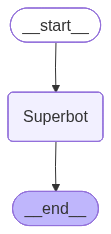

In [9]:
graph = StateGraph(State)

# node
graph.add_node("Superbot",superbot)

# edges 
graph.add_edge(START,"Superbot")
graph.add_edge("Superbot",END)

graph_builder = graph.compile()

##Display
from IPython.display import Image,display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [10]:
## Invocation

graph_builder.invoke({"messages":"HI My name is Tej and I like Cricket"})

{'messages': [HumanMessage(content='HI My name is Tej and I like Cricket', additional_kwargs={}, response_metadata={}, id='bb608565-aafb-4e1c-b797-8838c9f227d3'),
  AIMessage(content="Hello Tej! Nice to meet you! Cricket is a fantastic sport, isn't it? Which team do you support? Are you a fan of Virat Kohli, Rohit Sharma, or perhaps someone else? Do you play cricket yourself or just enjoy watching it? Let's chat!", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 58, 'prompt_tokens': 20, 'total_tokens': 78, 'completion_time': 0.131150511, 'completion_tokens_details': None, 'prompt_time': 0.000920622, 'prompt_tokens_details': None, 'queue_time': 0.310250838, 'total_time': 0.132071133}, 'model_name': 'meta-llama/llama-4-scout-17b-16e-instruct', 'system_fingerprint': 'fp_f0bb21cb36', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e9124-8bc4-73c1-9671-8cc1e31807a5-0', tool_calls=[], invalid_tool

### Streaming the responses

In [15]:
for event in graph_builder.stream({"messages":"Hello My name is Tej"}):
    print(event)

{'Superbot': {'messages': [AIMessage(content="Hello Tej! Nice to meet you! How's your day going so far?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 18, 'prompt_tokens': 16, 'total_tokens': 34, 'completion_time': 0.040610709, 'completion_tokens_details': None, 'prompt_time': 0.00132378, 'prompt_tokens_details': None, 'queue_time': 0.559205139, 'total_time': 0.041934489}, 'model_name': 'meta-llama/llama-4-scout-17b-16e-instruct', 'system_fingerprint': 'fp_79da0e0073', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e9128-eefd-7693-ae00-5210724e166f-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 16, 'output_tokens': 18, 'total_tokens': 34})]}}
